<a href="https://colab.research.google.com/github/aribarahmanii/Breasttumor/blob/main/sem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os, zipfile

In [2]:
import kagglehub
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Dataset downloaded to: /kaggle/input/breast-ultrasound-images-dataset


In [3]:
print(os.listdir(path))

['Dataset_BUSI_with_GT']


In [4]:
IMG_SIZE = 256
DATA_DIR = path

imgs_raw_list, masks_list, labels_list = [], [], []

classes = {'benign': 0, 'malignant': 1}

for cls_name, cls_label in classes.items():
    cls_dir = os.path.join(DATA_DIR, "Dataset_BUSI_with_GT", cls_name)
    files = sorted(os.listdir(cls_dir))
    image_files = [f for f in files if f.endswith('.png') and 'mask' not in f]

    for img_file in image_files:
        img_path = os.path.join(cls_dir, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        base_name = img_file.replace('.png', '')
        mask_files = [f for f in files if f.startswith(base_name + '_mask')]

        combined_mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype='float32')
        for mf in mask_files:
            m = cv2.imread(os.path.join(cls_dir, mf), cv2.IMREAD_GRAYSCALE)
            m = cv2.resize(m, (IMG_SIZE, IMG_SIZE))
            combined_mask = np.maximum(combined_mask, (m > 127).astype('float32'))

        imgs_raw_list.append(img)
        masks_list.append(combined_mask[..., np.newaxis])
        labels_list.append(cls_label)

imgs_raw = np.array(imgs_raw_list)
masks = np.array(masks_list)
labels = np.array(labels_list)
imgs_norm = (imgs_raw / 255.0)[..., np.newaxis]

print("imgs_raw:", imgs_raw.shape, "masks:", masks.shape, "labels:", labels.shape)

imgs_raw: (647, 256, 256) masks: (647, 256, 256, 1) labels: (647,)


In [5]:
from sklearn.model_selection import train_test_split

n = len(imgs_raw)
all_idx = np.arange(n)

idx_train, idx_temp = train_test_split(all_idx, test_size=0.3, stratify=labels, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, stratify=labels[idx_temp], random_state=42)

print("train:", len(idx_train), "val:", len(idx_val), "test:", len(idx_test))

train: 452 val: 97 test: 98


In [6]:
def dice_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    inter = np.sum(gt * pred)
    return (2. * inter + smooth) / (np.sum(gt) + np.sum(pred) + smooth)

def clean_mask(mask):
    mask_u8 = (mask > 0).astype('uint8')
    n_labels, labels_im, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    if n_labels <= 1:
        return mask_u8.astype('float32')
    h, w = mask_u8.shape
    best_label, best_area = 0, 0
    for lbl in range(1, n_labels):
        x, y, bw, bh, area = stats[lbl]
        touches_border = (x == 0 or y == 0 or x + bw == w or y + bh == h)
        if not touches_border and area > best_area:
            best_area, best_label = area, lbl
    return (labels_im == best_label).astype('float32')

In [7]:
!git clone https://github.com/bowang-lab/MedSAM.git
%cd MedSAM
!pip install -e .
%cd ..

Cloning into 'MedSAM'...
remote: Enumerating objects: 967, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 967 (delta 102), reused 95 (delta 95), pack-reused 842 (from 1)
Receiving objects: 100% (967/967), 62.52 MiB | 45.99 MiB/s, done.
Resolving deltas: 100% (477/477), done.
/content/MedSAM
Obtaining file:///content/MedSAM
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 136.6 MB/s eta 0:00:00
  Running 

In [8]:
!pip install gdown
import gdown
gdown.download(id="1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_", output="medsam_vit_b.pth", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_
From (redirected): https://drive.google.com/uc?id=1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_&confirm=t&uuid=68cdd707-418a-4786-bad0-b6e431f43d8b
To: /content/medsam_vit_b.pth
100%|██████████| 375M/375M [00:02<00:00, 163MB/s]


'medsam_vit_b.pth'

In [9]:
import sys
sys.path.append('MedSAM')
from segment_anything import sam_model_registry
import torch
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
medsam_model = sam_model_registry['vit_b'](checkpoint='medsam_vit_b.pth').to(device)
medsam_model.eval()

def get_bbox_from_mask(mask, pad=5):
    ys, xs = np.where(mask > 0.5)
    if len(xs) == 0:
        return None
    x0, x1 = max(0, xs.min() - pad), min(mask.shape[1], xs.max() + pad)
    y0, y1 = max(0, ys.min() - pad), min(mask.shape[0], ys.max() + pad)
    return np.array([x0, y0, x1, y1])

@torch.no_grad()
def medsam_inference(img_uint8, box, size=1024):
    img_rgb = np.stack([img_uint8]*3, axis=-1)
    img_resized = cv2.resize(img_rgb, (size, size))
    img_tensor = torch.tensor(img_resized).permute(2, 0, 1).unsqueeze(0).float().to(device) / 255.0

    image_embedding = medsam_model.image_encoder(img_tensor)
    box_scaled = box / np.array([img_uint8.shape[1], img_uint8.shape[0],
                                  img_uint8.shape[1], img_uint8.shape[0]]) * size
    box_t = torch.as_tensor(box_scaled, dtype=torch.float32, device=device).unsqueeze(0)

    sparse_emb, dense_emb = medsam_model.prompt_encoder(points=None, boxes=box_t, masks=None)
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=image_embedding,
        image_pe=medsam_model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse_emb,
        dense_prompt_embeddings=dense_emb,
        multimask_output=False,
    )
    pred = torch.sigmoid(low_res_logits)
    pred = F.interpolate(pred, size=(img_uint8.shape[0], img_uint8.shape[1]), mode='bilinear', align_corners=False)
    return (pred.squeeze().cpu().numpy() > 0.5).astype('float32')

medsam_dices = []
for i in idx_test[:5]:
    img_u8 = imgs_raw[i]
    gt = masks[i, ..., 0]
    box = get_bbox_from_mask(gt)
    if box is None:
        continue
    pred_mask = medsam_inference(img_u8, box)
    medsam_dices.append(dice_score(gt, pred_mask))

print('MedSAM mean Dice (5 samples):', np.mean(medsam_dices))

MedSAM mean Dice (5 samples): 0.9420969


In [10]:
medsam_dices_full = []
for i in idx_test:
    img_u8 = imgs_raw[i]
    gt = masks[i, ..., 0]
    box = get_bbox_from_mask(gt)
    if box is None:
        continue
    pred_mask = medsam_inference(img_u8, box)
    medsam_dices_full.append(dice_score(gt, pred_mask))

print(f'MedSAM mean Dice (full test set, n={len(medsam_dices_full)}):', np.mean(medsam_dices_full))

MedSAM mean Dice (full test set, n=98): 0.9361132


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x

def build_unet(input_size=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = layers.Input(input_size)
    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 64);     p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 128);    p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 256);    p4 = layers.MaxPooling2D()(c4)
    bn = conv_block(p4, 512)
    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(bn)
    u4 = layers.Concatenate()([u4, c4]); d4 = conv_block(u4, 256)
    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(d4)
    u3 = layers.Concatenate()([u3, c3]); d3 = conv_block(u3, 128)
    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(d3)
    u2 = layers.Concatenate()([u2, c2]); d2 = conv_block(u2, 64)
    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(d2)
    u1 = layers.Concatenate()([u1, c1]); d1 = conv_block(u1, 32)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d1)
    return models.Model(inputs, outputs, name='U-Net')

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true); y_pred_f = K.flatten(y_pred)
    inter = K.sum(y_true_f * y_pred_f)
    return (2. * inter + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + (1 - dice_coef(y_true, y_pred))

unet = build_unet()
unet.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=bce_dice_loss, metrics=[dice_coef])
unet.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[

 Total params: 7,771,297 (29.65 MB)

 Trainable params: 7,765,409 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [12]:
X_train, y_train = imgs_norm[idx_train], masks[idx_train]
X_val, y_val = imgs_norm[idx_val], masks[idx_val]
X_test, y_test = imgs_norm[idx_test], masks[idx_test]
print(X_train.shape, X_val.shape, X_test.shape)

(452, 256, 256, 1) (97, 256, 256, 1) (98, 256, 256, 1)


In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', mode='max', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6),
]

history = unet.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=16, callbacks=callbacks)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - dice_coef: 0.1705 - loss: 1.5804 - val_dice_coef: 0.1555 - val_loss: 1.4849 - learning_rate: 1.0000e-04
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 343ms/step - dice_coef: 0.2345 - loss: 1.3975 - val_dice_coef: 0.1518 - val_loss: 1.4180 - learning_rate: 1.0000e-04
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 350ms/step - dice_coef: 0.2658 - loss: 1.3014 - val_dice_coef: 0.1459 - val_loss: 1.3421 - learning_rate: 1.0000e-04
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 364ms/step - dice_coef: 0.2863 - loss: 1.2297 - val_dice_coef: 0.1377 - val_loss: 1.2867 - learning_rate: 1.0000e-04
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 366ms/step - dice_coef: 0.3130 - loss: 1.1564 - val_dice_coef: 0.1292 - val_loss: 1.2525 - learning_rate: 1.0000e-04
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 355ms/step - dice_coef: 0.3312 - loss: 1.1036 - val_dice_coef: 0.1228 - val_loss: 1.2411 - learning_rate: 1.0000e-04
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s

In [14]:
unet_preds = unet.predict(X_test)
unet_dices = [dice_score(y_test[k, ..., 0], unet_preds[k, ..., 0]) for k in range(len(X_test))]
print('U-Net mean Dice (full test set):', np.mean(unet_dices))

4/4 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step
U-Net mean Dice (full test set): 5.0810844e-10


In [15]:
unet_preds = unet.predict(X_test)
unet_dices = [dice_score(y_test[k, ..., 0], unet_preds[k, ..., 0]) for k in range(len(X_test))]
print('U-Net mean Dice (full test set):', np.mean(unet_dices))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step
U-Net mean Dice (full test set): 5.0810844e-10


In [16]:
def pixel_accuracy(gt, pred):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    return np.sum(gt == pred) / len(gt)

def precision_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    tp = np.sum(gt * pred)
    fp = np.sum((1 - gt) * pred)
    return (tp + smooth) / (tp + fp + smooth)

def sensitivity_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    tp = np.sum(gt * pred)
    fn = np.sum(gt * (1 - pred))
    return (tp + smooth) / (tp + fn + smooth)

def specificity_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    tn = np.sum((1 - gt) * (1 - pred))
    fp = np.sum((1 - gt) * pred)
    return (tn + smooth) / (tn + fp + smooth)

def iou_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    inter = np.sum(gt * pred)
    union = np.sum(gt) + np.sum(pred) - inter
    return (inter + smooth) / (union + smooth)

def evaluate_all(gt, pred):
    return {
        'dice': dice_score(gt, pred),
        'iou': iou_score(gt, pred),
        'accuracy': pixel_accuracy(gt, pred),
        'precision': precision_score(gt, pred),
        'sensitivity': sensitivity_score(gt, pred),
        'specificity': specificity_score(gt, pred),
    }

metric_names = ['dice', 'iou', 'accuracy', 'precision', 'sensitivity', 'specificity']

unet_preds = unet.predict(X_test)
unet_results = {m: [] for m in metric_names}
for k in range(len(X_test)):
    scores = evaluate_all(y_test[k, ..., 0], unet_preds[k, ..., 0])
    for m in metric_names:
        unet_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(unet_results[m]):>15.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step
Metric              Mean Score
------------------------------
Dice                    0.0000
Iou                     0.0000
Accuracy                0.8943
Precision               1.0000
Sensitivity             0.0000
Specificity             1.0000


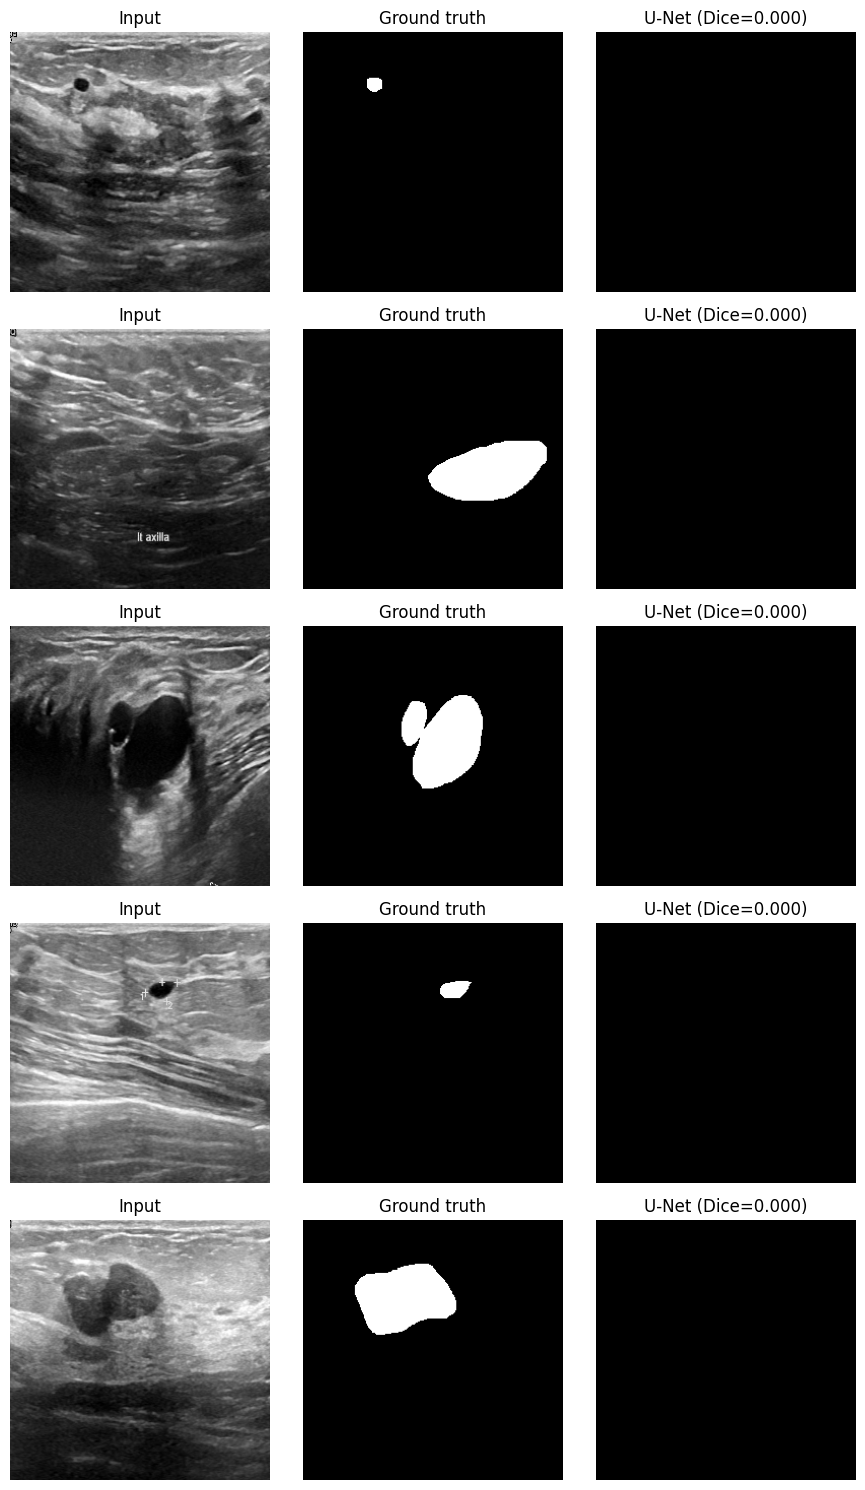

In [17]:
fig, axes = plt.subplots(5, 3, figsize=(9, 15))
for row, idx_num in enumerate(range(5)):
    k = idx_num
    axes[row, 0].imshow(X_test[k, ..., 0], cmap='gray')
    axes[row, 0].set_title('Input')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(y_test[k, ..., 0], cmap='gray')
    axes[row, 1].set_title('Ground truth')
    axes[row, 1].axis('off')

    pred_binary = unet_preds[k, ..., 0] > 0.5
    d = dice_score(y_test[k, ..., 0], pred_binary)
    axes[row, 2].imshow(pred_binary, cmap='gray')
    axes[row, 2].set_title(f'U-Net (Dice={d:.3f})')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

In [18]:
def build_classifier(input_size=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = layers.Input(input_size)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name='last_conv')(x)
    gap = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(1, activation='sigmoid')(gap)
    return models.Model(inputs, out, name='classifier')

clf = build_classifier()
clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
clf.fit(imgs_norm[idx_train], labels[idx_train].astype('float32'),
        validation_data=(imgs_norm[idx_val], labels[idx_val].astype('float32')),
        epochs=30, batch_size=16)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - accuracy: 0.6571 - loss: 0.6348 - val_accuracy: 0.6804 - val_loss: 0.6248
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6748 - loss: 0.6350 - val_accuracy: 0.6804 - val_loss: 0.6206
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6748 - loss: 0.6323 - val_accuracy: 0.6804 - val_loss: 0.6261
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6748 - loss: 0.6248 - val_accuracy: 0.6804 - val_loss: 0.6153
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6748 - loss: 0.6202 - val_accuracy: 0.6804 - val_loss: 0.6086
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6748 - loss: 0.6174 - val_accuracy: 0.6804 - val_loss: 0.6271
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6748 - loss: 0.5991 - val_accuracy: 0.6804 - val_loss: 0.6480
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6748 - loss: 0.6075 - val_accuracy: 0.6804 - 

In [19]:
def grad_cam(model, img_array, layer_name='last_conv'):
    grad_model = models.Model([model.inputs], [model.get_layer(layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array[np.newaxis, ...])
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def gradcam_to_mask(heatmap, size=IMG_SIZE, thresh=0.5):
    return (cv2.resize(heatmap, (size, size)) > thresh).astype('float32')

In [20]:
gradcam_results = {m: [] for m in metric_names}
gradcam_preds_binary = []

for i in idx_test:
    heatmap = grad_cam(clf, imgs_norm[i])
    pred_mask = clean_mask(gradcam_to_mask(heatmap))
    gradcam_preds_binary.append(pred_mask)
    scores = evaluate_all(masks[i, ..., 0], pred_mask)
    for m in metric_names:
        gradcam_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(gradcam_results[m]):>15.4f}")

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_50']]
Received: inputs=Tensor(shape=(1, 256, 256, 1))
  warnings.warn(msg)


Metric              Mean Score
------------------------------
Dice                    0.1382
Iou                     0.0812
Accuracy                0.3263
Precision               0.1816
Sensitivity             0.7297
Specificity             0.3045


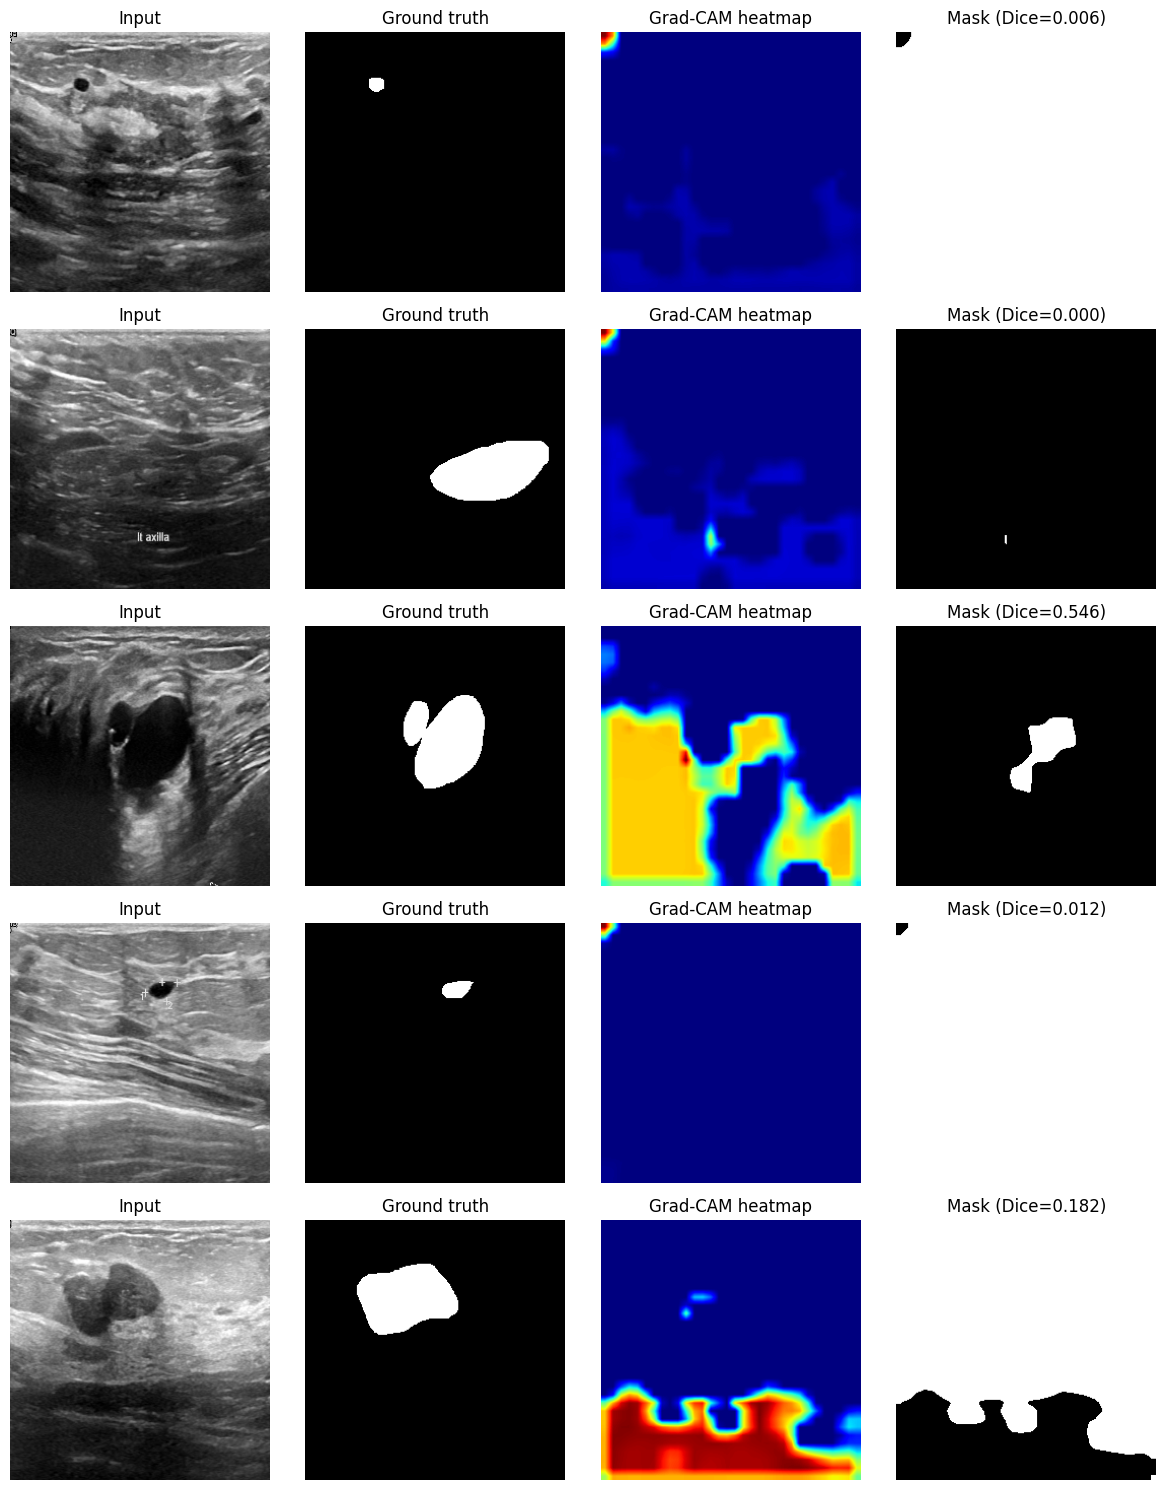

In [21]:
fig, axes = plt.subplots(5, 4, figsize=(12, 15))
for row, i in enumerate(idx_test[:5]):
    img = imgs_norm[i]
    gt = masks[i, ..., 0]
    heatmap = grad_cam(clf, img)
    pred_mask = clean_mask(gradcam_to_mask(heatmap))
    d = dice_score(gt, pred_mask)

    axes[row, 0].imshow(img[..., 0], cmap='gray'); axes[row, 0].set_title('Input'); axes[row, 0].axis('off')
    axes[row, 1].imshow(gt, cmap='gray'); axes[row, 1].set_title('Ground truth'); axes[row, 1].axis('off')
    axes[row, 2].imshow(cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE)), cmap='jet'); axes[row, 2].set_title('Grad-CAM heatmap'); axes[row, 2].axis('off')
    axes[row, 3].imshow(pred_mask, cmap='gray'); axes[row, 3].set_title(f'Mask (Dice={d:.3f})'); axes[row, 3].axis('off')

plt.tight_layout()
plt.show()

In [22]:
print(f"{'Metric':<15}{'U-Net':>15}{'Grad-CAM':>15}")
print('-' * 45)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(unet_results[m]):>15.4f}{np.mean(gradcam_results[m]):>15.4f}")

Metric                   U-Net       Grad-CAM
---------------------------------------------
Dice                    0.0000         0.1382
Iou                     0.0000         0.0812
Accuracy                0.8943         0.3263
Precision               1.0000         0.1816
Sensitivity             0.0000         0.7297
Specificity             1.0000         0.3045


In [23]:
medsam_results = {m: [] for m in metric_names}

for i in idx_test:
    img_u8 = imgs_raw[i]
    gt = masks[i, ..., 0]
    box = get_bbox_from_mask(gt)
    if box is None:
        continue
    pred_mask = medsam_inference(img_u8, box)
    scores = evaluate_all(gt, pred_mask)
    for m in metric_names:
        medsam_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(medsam_results[m]):>15.4f}")

Metric              Mean Score
------------------------------
Dice                    0.9361
Iou                     0.8820
Accuracy                0.9852
Precision               0.9256
Sensitivity             0.9495
Specificity             0.9888


In [24]:
print(f"{'Metric':<15}{'U-Net':>15}{'Grad-CAM':>15}{'MedSAM':>15}")
print('-' * 60)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(unet_results[m]):>15.4f}{np.mean(gradcam_results[m]):>15.4f}{np.mean(medsam_results[m]):>15.4f}")

Metric                   U-Net       Grad-CAM         MedSAM
------------------------------------------------------------
Dice                    0.0000         0.1382         0.9361
Iou                     0.0000         0.0812         0.8820
Accuracy                0.8943         0.3263         0.9852
Precision               1.0000         0.1816         0.9256
Sensitivity             0.0000         0.7297         0.9495
Specificity             1.0000         0.3045         0.9888


In [25]:
import torch, torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from scipy import ndimage

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

class BUSIInstanceDataset(Dataset):
    def __init__(self, indices): self.indices = indices
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        i = self.indices[idx]
        img = imgs_raw[i]; mask = masks[i, ..., 0]
        labeled, n = ndimage.label(mask > 0.5)
        boxes, inst_masks, cls_labels = [], [], []
        for inst_id in range(1, n + 1):
            inst_mask = (labeled == inst_id)
            ys, xs = np.where(inst_mask)
            if len(xs) == 0: continue
            boxes.append([xs.min(), ys.min(), xs.max(), ys.max()])
            inst_masks.append(inst_mask); cls_labels.append(1)
        if len(boxes) == 0:
            boxes = [[0, 0, 1, 1]]; inst_masks = [np.zeros_like(mask, dtype=bool)]; cls_labels = [1]
        img_rgb = np.stack([img]*3, axis=0).astype('float32') / 255.0
        target = {'boxes': torch.as_tensor(boxes, dtype=torch.float32),
                  'labels': torch.as_tensor(cls_labels, dtype=torch.int64),
                  'masks': torch.as_tensor(np.stack(inst_masks), dtype=torch.uint8),
                  'image_id': torch.tensor([i])}
        return torch.tensor(img_rgb), target

def collate_fn(batch): return tuple(zip(*batch))
train_loader = DataLoader(BUSIInstanceDataset(idx_train), batch_size=4, shuffle=True, collate_fn=collate_fn)

Using device: cuda


In [26]:
mrcnn = maskrcnn_resnet50_fpn(weights='DEFAULT')
in_feat = mrcnn.roi_heads.box_predictor.cls_score.in_features
mrcnn.roi_heads.box_predictor = FastRCNNPredictor(in_feat, 2)
in_feat_mask = mrcnn.roi_heads.mask_predictor.conv5_mask.in_channels
mrcnn.roi_heads.mask_predictor = MaskRCNNPredictor(in_feat_mask, 256, 2)
mrcnn = mrcnn.to(device)

optimizer = torch.optim.SGD(mrcnn.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
print("Model ready")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 161MB/s]


Model ready


In [28]:
class BUSIInstanceDataset(Dataset):
    def __init__(self, indices): self.indices = indices
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        i = self.indices[idx]
        img = imgs_raw[i]; mask = masks[i, ..., 0]
        labeled, n = ndimage.label(mask > 0.5)
        boxes, inst_masks, cls_labels = [], [], []
        for inst_id in range(1, n + 1):
            inst_mask = (labeled == inst_id)
            ys, xs = np.where(inst_mask)
            if len(xs) < 10:  # skip tiny/noise blobs outright (fewer than 10 pixels)
                continue
            x0, x1 = int(xs.min()), int(xs.max()) + 1   # +1 guarantees positive width
            y0, y1 = int(ys.min()), int(ys.max()) + 1   # +1 guarantees positive height
            x1 = min(x1, mask.shape[1])                  # clip to image bounds
            y1 = min(y1, mask.shape[0])
            if x1 - x0 < 4 or y1 - y0 < 4:                # extra safety margin before resize
                continue
            boxes.append([x0, y0, x1, y1])
            inst_masks.append(inst_mask)
            cls_labels.append(1)

        if len(boxes) == 0:
            boxes = [[10, 10, 20, 20]]  # safely-sized dummy box, well clear of zero-area
            inst_masks = [np.zeros_like(mask, dtype=bool)]
            cls_labels = [1]

        img_rgb = np.stack([img]*3, axis=0).astype('float32') / 255.0
        target = {'boxes': torch.as_tensor(boxes, dtype=torch.float32),
                  'labels': torch.as_tensor(cls_labels, dtype=torch.int64),
                  'masks': torch.as_tensor(np.stack(inst_masks), dtype=torch.uint8),
                  'image_id': torch.tensor([i])}
        return torch.tensor(img_rgb), target

train_loader = DataLoader(BUSIInstanceDataset(idx_train), batch_size=4, shuffle=True, collate_fn=collate_fn)
print("Dataset ready, size:", len(train_loader.dataset))

Dataset ready, size: 452


In [29]:
for epoch in range(10):
    mrcnn.train()
    epoch_loss = 0
    for imgs_b, targets in train_loader:
        imgs_b = [im.to(device) for im in imgs_b]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = mrcnn(imgs_b, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    lr_scheduler.step()
    print(f'Epoch {epoch+1}/10 — loss: {epoch_loss/len(train_loader):.4f}')

Epoch 1/10 — loss: 0.4482
Epoch 2/10 — loss: 0.3514
Epoch 3/10 — loss: 0.3043
Epoch 4/10 — loss: 0.2704
Epoch 5/10 — loss: 0.2427
Epoch 6/10 — loss: 0.1993
Epoch 7/10 — loss: 0.1743
Epoch 8/10 — loss: 0.1622
Epoch 9/10 — loss: 0.1503
Epoch 10/10 — loss: 0.1428


In [30]:
mrcnn.eval()
mrcnn_results = {m: [] for m in metric_names}
mrcnn_preds_store = {}

with torch.no_grad():
    for i in idx_test:
        img_rgb = np.stack([imgs_raw[i]]*3, axis=0).astype('float32') / 255.0
        img_t = torch.tensor(img_rgb).unsqueeze(0).to(device)
        pred = mrcnn(img_t)[0]

        gt = masks[i, ..., 0]
        keep = pred['scores'] > 0.5
        if len(pred['masks']) > 0 and keep.sum() > 0:
            pred_mask = pred['masks'][keep, 0].max(dim=0)[0].cpu().numpy() > 0.5
        else:
            pred_mask = np.zeros_like(gt)

        pred_mask = pred_mask.astype('float32')
        mrcnn_preds_store[i] = pred_mask
        scores = evaluate_all(gt, pred_mask)
        for m in metric_names:
            mrcnn_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(mrcnn_results[m]):>15.4f}")

Metric              Mean Score
------------------------------
Dice                    0.7401
Iou                     0.6686
Accuracy                0.9513
Precision               0.8149
Sensitivity             0.8078
Specificity             0.9688


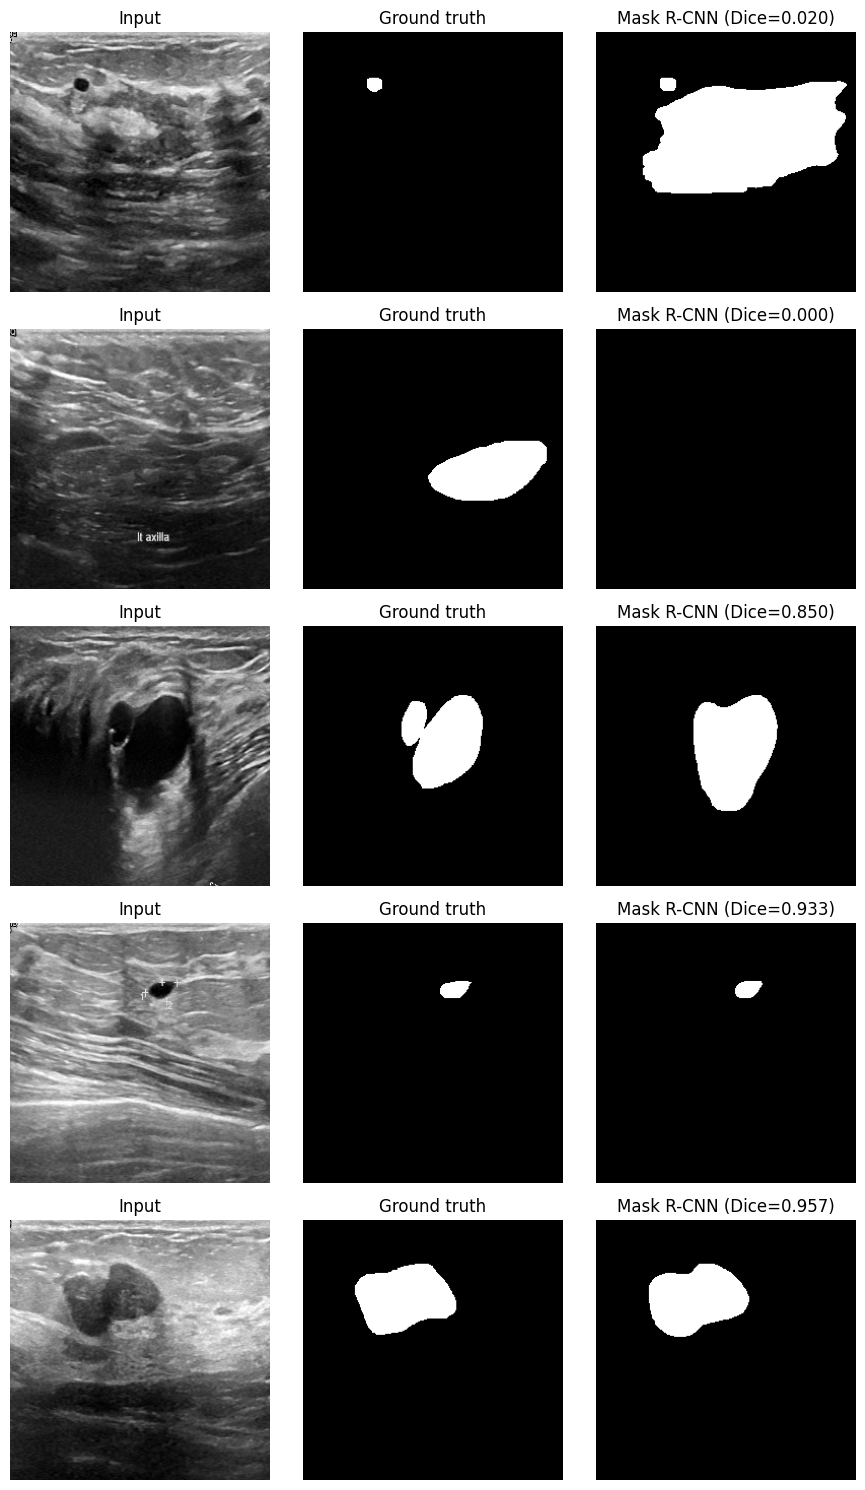

In [31]:
fig, axes = plt.subplots(5, 3, figsize=(9, 15))
for row, i in enumerate(idx_test[:5]):
    gt = masks[i, ..., 0]
    pred_mask = mrcnn_preds_store[i]
    d = dice_score(gt, pred_mask)

    axes[row, 0].imshow(imgs_raw[i], cmap='gray'); axes[row, 0].set_title('Input'); axes[row, 0].axis('off')
    axes[row, 1].imshow(gt, cmap='gray'); axes[row, 1].set_title('Ground truth'); axes[row, 1].axis('off')
    axes[row, 2].imshow(pred_mask, cmap='gray'); axes[row, 2].set_title(f'Mask R-CNN (Dice={d:.3f})'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

In [32]:
print(f"{'Metric':<15}{'U-Net':>13}{'Grad-CAM':>13}{'Mask R-CNN':>13}{'MedSAM':>13}")
print('-' * 65)
for m in metric_names:
    print(f"{m.capitalize():<15}"
          f"{np.mean(unet_results[m]):>13.4f}"
          f"{np.mean(gradcam_results[m]):>13.4f}"
          f"{np.mean(mrcnn_results[m]):>13.4f}"
          f"{np.mean(medsam_results[m]):>13.4f}")

Metric                 U-Net     Grad-CAM   Mask R-CNN       MedSAM
-----------------------------------------------------------------
Dice                  0.0000       0.1382       0.7401       0.9361
Iou                   0.0000       0.0812       0.6686       0.8820
Accuracy              0.8943       0.3263       0.9513       0.9852
Precision             1.0000       0.1816       0.8149       0.9256
Sensitivity           0.0000       0.7297       0.8078       0.9495
Specificity           1.0000       0.3045       0.9688       0.9888


In [33]:
print('unet' in dir())  # check the trained model is still there

True


In [34]:
X_test, y_test = imgs_norm[idx_test], masks[idx_test]

unet_preds = unet.predict(X_test)
print("Prediction stats — min:", unet_preds.min(), "max:", unet_preds.max(), "mean:", unet_preds.mean())

unet_results = {m: [] for m in metric_names}
for k in range(len(X_test)):
    scores = evaluate_all(y_test[k, ..., 0], unet_preds[k, ..., 0])
    for m in metric_names:
        unet_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(unet_results[m]):>15.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step
Prediction stats — min: 0.4598365 max: 0.49997866 mean: 0.47788367
Metric              Mean Score
------------------------------
Dice                    0.0000
Iou                     0.0000
Accuracy                0.8943
Precision               1.0000
Sensitivity             0.0000
Specificity             1.0000


In [35]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', mode='max', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6),
]

history = unet.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=16, callbacks=callbacks)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 342ms/step - dice_coef: 0.2383 - loss: 1.4053 - val_dice_coef: 0.1526 - val_loss: 1.4323 - learning_rate: 5.0000e-05
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 363ms/step - dice_coef: 0.2487 - loss: 1.3555 - val_dice_coef: 0.1486 - val_loss: 1.3730 - learning_rate: 5.0000e-05
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 372ms/step - dice_coef: 0.2733 - loss: 1.2827 - val_dice_coef: 0.1434 - val_loss: 1.3190 - learning_rate: 5.0000e-05
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 360ms/step - dice_coef: 0.2897 - loss: 1.2457 - val_dice_coef: 0.1377 - val_loss: 1.2830 - learning_rate: 5.0000e-05
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 365ms/step - dice_coef: 0.2977 - loss: 1.2086 - val_dice_coef: 0.1317 - val_loss: 1.2605 - learning_rate: 5.0000e-05
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 383ms/step - dice_coef: 0.3131 - loss: 1.1486 - val_dice_coef: 0.1255 - val_loss: 1.2448 - learning_rate: 5.0000e-05
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1

In [36]:
print('X_train' in dir(), 'y_train' in dir())

True True


In [37]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', mode='max', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6),
]

history = unet.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=16, callbacks=callbacks)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 345ms/step - dice_coef: 0.6921 - loss: 0.4158 - val_dice_coef: 0.5635 - val_loss: 0.6602 - learning_rate: 6.2500e-06
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 346ms/step - dice_coef: 0.7021 - loss: 0.4025 - val_dice_coef: 0.5502 - val_loss: 0.6698 - learning_rate: 6.2500e-06
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 356ms/step - dice_coef: 0.6961 - loss: 0.4082 - val_dice_coef: 0.5532 - val_loss: 0.6621 - learning_rate: 6.2500e-06
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 362ms/step - dice_coef: 0.7090 - loss: 0.3822 - val_dice_coef: 0.5455 - val_loss: 0.6680 - learning_rate: 6.2500e-06
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 359ms/step - dice_coef: 0.7102 - loss: 0.3885 - val_dice_coef: 0.5450 - val_loss: 0.6709 - learning_rate: 6.2500e-06
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 375ms/step - dice_coef: 0.6985 - loss: 0.4028 - val_dice_coef: 0.5387 - val_loss: 0.6753 - learning_rate: 6.2500e-06
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1

In [38]:
unet_preds = unet.predict(X_test)
print("Prediction stats — min:", unet_preds.min(), "max:", unet_preds.max(), "mean:", unet_preds.mean())

unet_results = {m: [] for m in metric_names}
for k in range(len(X_test)):
    scores = evaluate_all(y_test[k, ..., 0], unet_preds[k, ..., 0])
    for m in metric_names:
        unet_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(unet_results[m]):>15.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step
Prediction stats — min: 3.164122e-05 max: 1.0 mean: 0.08939851
Metric              Mean Score
------------------------------
Dice                    0.6108
Iou                     0.5215
Accuracy                0.9355
Precision               0.7826
Sensitivity             0.5827
Specificity             0.9902


In [39]:
print(f"{'Metric':<15}{'U-Net':>13}{'Grad-CAM':>13}{'Mask R-CNN':>13}{'MedSAM':>13}")
print('-' * 65)
for m in metric_names:
    print(f"{m.capitalize():<15}"
          f"{np.mean(unet_results[m]):>13.4f}"
          f"{np.mean(gradcam_results[m]):>13.4f}"
          f"{np.mean(mrcnn_results[m]):>13.4f}"
          f"{np.mean(medsam_results[m]):>13.4f}")

Metric                 U-Net     Grad-CAM   Mask R-CNN       MedSAM
-----------------------------------------------------------------
Dice                  0.6108       0.1382       0.7401       0.9361
Iou                   0.5215       0.0812       0.6686       0.8820
Accuracy              0.9355       0.3263       0.9513       0.9852
Precision             0.7826       0.1816       0.8149       0.9256
Sensitivity           0.5827       0.7297       0.8078       0.9495
Specificity           0.9902       0.3045       0.9688       0.9888
